# Regressão Softmax com dados do MNIST

## Objetivo

O objetivo deste notebook é ilustrar o uso de praticamente a mesma rede desenvolvida para a classificação das flores Íris, porém agora com o problema de classificação de dígitos manuscritos utilizando o dataset MNIST.
As principais diferenças são:
- tipo do dado, agora imagem com muito atributos: 28 x 28 pixels
- número de amostras, muito maior, 60 mil
Neste exercício será possível a interpretação do significado dos parâmetros treinados

## Importação das bibliotecas

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable

import torchvision

## Carregamento dos dados do MNIST

In [3]:
! git clone https://github.com/vcasadei/MNIST.git

Cloning into 'MNIST'...
remote: Enumerating objects: 10, done.
remote: Total 10 (delta 0), reused 0 (delta 0), pack-reused 10 (from 1)
Receiving objects: 100% (10/10), 11.01 MiB | 8.67 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [4]:
!ls MNIST

processed  raw


In [5]:
dataset_dir = 'MNIST/'

x_train, y_train = torch.load(dataset_dir + 'processed/training.pt')

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 60000

Dimensões dos dados das imagens:    torch.Size([60000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0, dtype=torch.uint8) tensor(255, dtype=torch.uint8)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento, normalização e seleção dos dados do MNIST

Neste exemplo utilizaremos apenas 1000 amostras de treinamento.

In [6]:
x_train = x_train.float()

x_train = x_train / 255.

if True:
    n_samples_train = 1000

    x_train = x_train[:n_samples_train]
    y_train = y_train[:n_samples_train]

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 1000

Dimensões dos dados das imagens:    torch.Size([1000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0.) tensor(1.)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


In [7]:
print("Valores mínimo e máximo de Y:", torch.min(y_train), torch.max(y_train))

Valores mínimo e máximo de Y: tensor(0) tensor(9)


### Carregamento e normalização dos dados de validação

In [8]:
x_val, y_val = torch.load(dataset_dir + 'processed/test.pt')

x_val = x_val.float()
x_val = x_val / 255.

# Limit validation samples for consistency with training set, if needed
# If you want to use the full test set for validation, comment this block
if True:
    n_samples_val = 200 # Using a smaller validation set for demonstration

    x_val = x_val[:n_samples_val]
    y_val = y_val[:n_samples_val]

print("Amostras de validação:", x_val.size(0))

print("\nDimensões dos dados das imagens de validação:   ", x_val.size())
print("Valores mínimo e máximo dos pixels de validação:", torch.min(x_val), torch.max(x_val))
print("Tipo dos dados das imagens de validação:        ", type(x_val))
print("Tipo das classes das imagens de validação:      ", type(y_val))

Amostras de validação: 200

Dimensões dos dados das imagens de validação:    torch.Size([200, 28, 28])
Valores mínimo e máximo dos pixels de validação: tensor(0.) tensor(1.)
Tipo dos dados das imagens de validação:         <class 'torch.Tensor'>
Tipo das classes das imagens de validação:       <class 'torch.Tensor'>


### Visualizando os dados

(np.float64(-0.5), np.float64(232.5), np.float64(87.5), np.float64(-0.5))

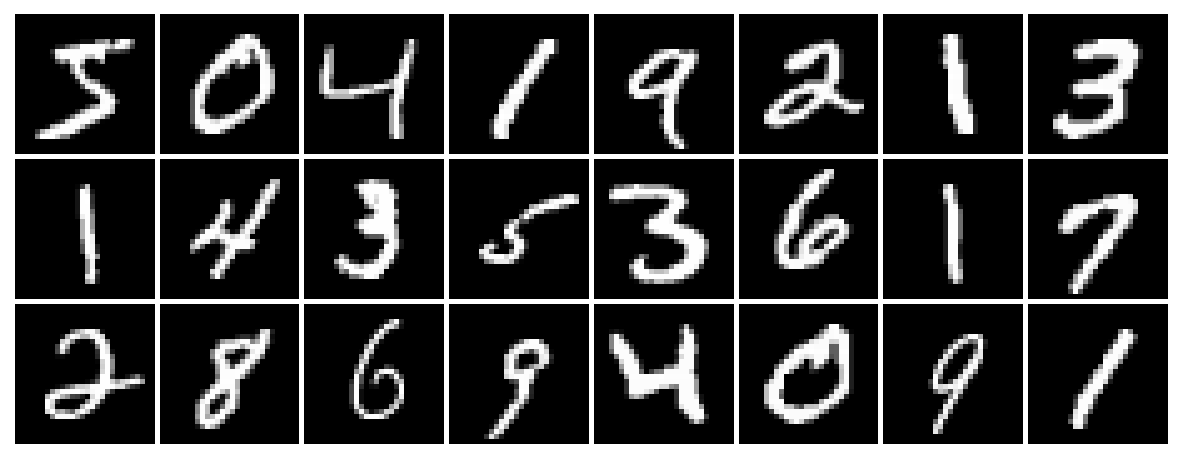

In [9]:
n_samples = 24

# cria um grid com as imagens
grid = torchvision.utils.make_grid(x_train[:n_samples].unsqueeze(dim=1), pad_value=1.0, padding=1)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off')

### Visualizando uma imagem com o matplotlib

class: tensor(5)


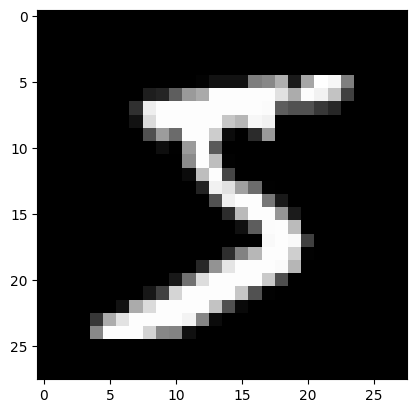

In [10]:
image  = x_train[0]
target = y_train[0]

plt.imshow(image.numpy(), cmap='gray')
print('class:', target)

In [11]:
x_train[0].view(-1, 28*28).shape

torch.Size([1, 784])

In [12]:
x_train[0].view(-1, 28*28)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

## Modelo

In [13]:
model = torch.nn.Linear(784, 10) # 28*28 atributos de entrada e 10 neurônios na sáida

### Testando um predict com poucas amostras

In [14]:
pred = model(x_train[:5].view(-1, 28*28))

In [15]:
xin = x_train[:5].view(-1,28*28)
score = model(xin)
score

tensor([[ 0.5753,  0.2010,  0.0902, -0.2072, -0.0921, -0.0505, -0.3511,  0.3303,
          0.1295, -0.1076],
        [ 0.3762, -0.0103,  0.0965, -0.2373, -0.1890, -0.2845, -0.1447,  0.5856,
          0.2118, -0.1003],
        [-0.0697, -0.0897, -0.2056,  0.1331,  0.2189, -0.1490,  0.1011, -0.0263,
          0.3908, -0.1875],
        [ 0.2771,  0.4804, -0.0138, -0.0070, -0.0015, -0.3250, -0.0840,  0.1702,
          0.2583, -0.0185],
        [ 0.1397,  0.0210, -0.0734,  0.0172,  0.1430, -0.0330,  0.1688,  0.0780,
          0.6215, -0.1204]], grad_fn=<AddmmBackward0>)

In [16]:
import torch.nn.functional as F
prob = F.softmax(score, dim=1)
prob

tensor([[0.1631, 0.1121, 0.1004, 0.0746, 0.0837, 0.0872, 0.0646, 0.1276, 0.1044,
         0.0824],
        [0.1359, 0.0923, 0.1028, 0.0736, 0.0772, 0.0702, 0.0807, 0.1676, 0.1153,
         0.0844],
        [0.0906, 0.0888, 0.0791, 0.1109, 0.1209, 0.0837, 0.1074, 0.0946, 0.1435,
         0.0805],
        [0.1197, 0.1467, 0.0895, 0.0901, 0.0906, 0.0656, 0.0835, 0.1076, 0.1175,
         0.0891],
        [0.1022, 0.0908, 0.0826, 0.0904, 0.1025, 0.0860, 0.1052, 0.0961, 0.1655,
         0.0788]], grad_fn=<SoftmaxBackward0>)

In [17]:
torch.max(prob, 1)

torch.return_types.max(
values=tensor([0.1631, 0.1676, 0.1435, 0.1467, 0.1655], grad_fn=<MaxBackward0>),
indices=tensor([0, 7, 8, 1, 8]))

## Treinamento

### Inicialização dos parâmetros

In [18]:
epochs = 100
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos pesos

In [19]:
import numpy
losses = []
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = x_train.view(-1, 28 * 28)
    # Predict da rede
    outputs = model(inputs)

    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, y_train)

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)

    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()


### Laço de treinamento dos pesos (com validação e armazenamento de métricas)

In [20]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for i in range(epochs):
    # Passada de treinamento
    inputs_train = x_train.view(-1, 28 * 28)
    outputs_train = model(inputs_train)
    loss_train = criterion(outputs_train, y_train)

    # Zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss_train.backward()
    optimizer.step()

    train_losses.append(loss_train.item())

    _, predicts_train = torch.max(outputs_train, 1)
    accuracy_train = (predicts_train.data.numpy() == y_train.numpy()).mean()
    train_accuracies.append(accuracy_train)

    # Passada de validação
    with torch.no_grad(): # Desabilita o cálculo de gradientes para validação
        inputs_val = x_val.view(-1, 28 * 28)
        outputs_val = model(inputs_val)
        loss_val = criterion(outputs_val, y_val)
        val_losses.append(loss_val.item())

        _, predicts_val = torch.max(outputs_val, 1)
        accuracy_val = (predicts_val.data.numpy() == y_val.numpy()).mean()
        val_accuracies.append(accuracy_val)

    print(f'Epoch [{i+1}/{epochs}], ' \
          f'Train Loss: {loss_train.item():.4f}, ' \
          f'Train Acc: {accuracy_train:.4f}, ' \
          f'Val Loss: {loss_val.item():.4f}, ' \
          f'Val Acc: {accuracy_val:.4f}')

Epoch [1/100], Train Loss: 0.2639, Train Acc: 0.9440, Val Loss: 0.3912, Val Acc: 0.8950
Epoch [2/100], Train Loss: 0.2626, Train Acc: 0.9440, Val Loss: 0.3902, Val Acc: 0.8950
Epoch [3/100], Train Loss: 0.2613, Train Acc: 0.9440, Val Loss: 0.3893, Val Acc: 0.8950
Epoch [4/100], Train Loss: 0.2600, Train Acc: 0.9440, Val Loss: 0.3884, Val Acc: 0.8950
Epoch [5/100], Train Loss: 0.2587, Train Acc: 0.9450, Val Loss: 0.3875, Val Acc: 0.8950
Epoch [6/100], Train Loss: 0.2575, Train Acc: 0.9450, Val Loss: 0.3866, Val Acc: 0.8950
Epoch [7/100], Train Loss: 0.2562, Train Acc: 0.9460, Val Loss: 0.3858, Val Acc: 0.8950
Epoch [8/100], Train Loss: 0.2550, Train Acc: 0.9460, Val Loss: 0.3849, Val Acc: 0.8950
Epoch [9/100], Train Loss: 0.2538, Train Acc: 0.9460, Val Loss: 0.3841, Val Acc: 0.8950
Epoch [10/100], Train Loss: 0.2526, Train Acc: 0.9470, Val Loss: 0.3833, Val Acc: 0.8950
Epoch [11/100], Train Loss: 0.2514, Train Acc: 0.9470, Val Loss: 0.3825, Val Acc: 0.8950
Epoch [12/100], Train Loss: 0.

In [21]:
print('Final loss:', loss.item())

Final loss: 0.26523375511169434


### Visualizando gráfico de perda durante o treinamento

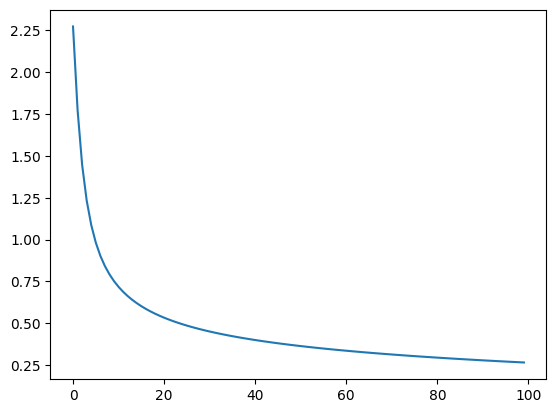

In [22]:
plt.plot(losses)

### Visualizando gráficos de perda e acurácia durante o treinamento

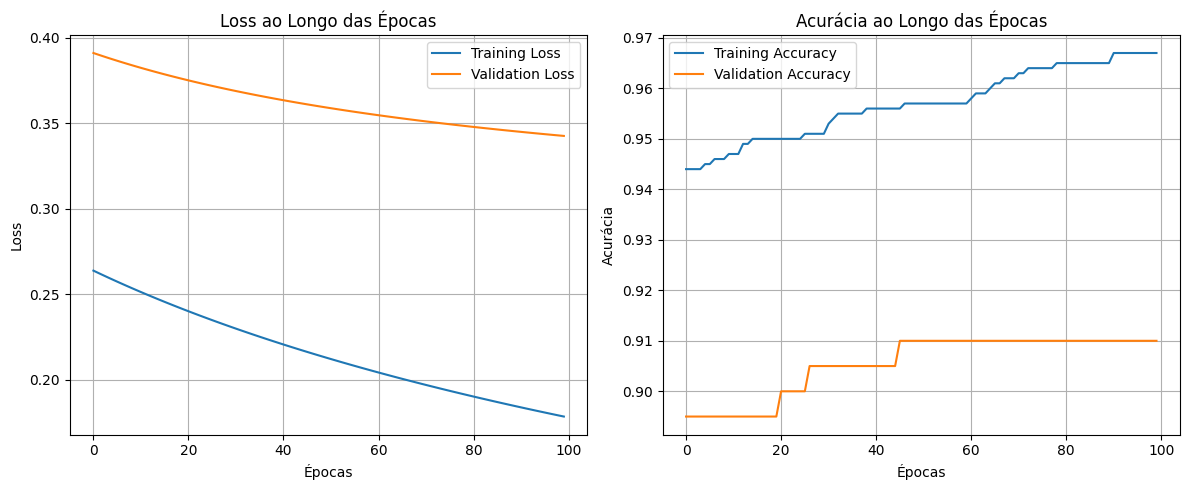

In [23]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Acurácia ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Avaliação

### Acurácia tanto no conjunto de treinamento como no conjunto de testes

In [24]:
def predict(model, input_data):
    outputs = model(Variable(input_data))
    _, predicts = torch.max(outputs, 1)

    return predicts.data

y_pred = predict(model, x_train.view(-1, 28*28))
accuracy = (y_pred.numpy() == y_train.numpy()).mean()
print('Accuracy:', accuracy)

Accuracy: 0.967


### Matriz de confusão com dados de treinamento e teste

In [25]:
print('Matriz de confusão:')
pd.crosstab(y_pred.numpy(), y_train.numpy())

Matriz de confusão:


col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,97,0,1,0,0,0,0,0,0,2
1,0,112,1,0,0,0,0,2,1,0
2,0,0,92,2,0,1,0,1,0,0
3,0,0,0,90,0,1,0,0,0,0
4,0,0,0,0,104,1,0,1,0,2
5,0,2,0,1,0,87,0,0,1,1
6,0,0,1,0,0,1,94,0,0,0
7,0,0,1,0,0,0,0,113,0,2
8,0,1,2,0,0,0,0,0,85,0


## Visualizando a matriz de pesos treinados

Observe que a matriz de peso treinado para cada classe mostra a importância dos pesos associados aos caracteres de cada classe.

weights: torch.Size([10, 784])
bias:    torch.Size([10])


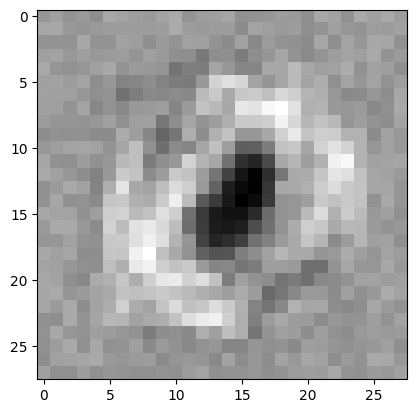

In [26]:
weights = model.state_dict()['weight']
print('weights:', weights.shape)

bias = model.state_dict()['bias']
print('bias:   ', bias.shape)

# Visualizando pesos da classe 3
plt.imshow(weights[0, :].numpy().reshape((28,28)),cmap = 'gray')
plt.show()

### Visualizando os pesos de todas as classes

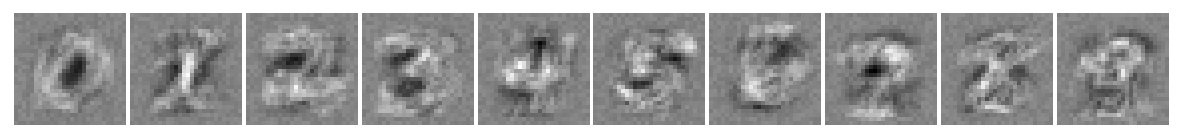

In [27]:
# cria um grid com as imagens
grid = torchvision.utils.make_grid(weights.view(-1, 1, 28, 28), normalize=True, pad_value=1.0, padding=1, nrow=10)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off');

### Diagrama da regressão softmax com visualização dos pesos W

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoSoftmaxArgmaxNMIST.png)

# Atividades

## Exercícios

- 1) Insira código no laço do treinamento para que no final de cada época,
     seja impresso: o número da época e a perda e a acurácia

- 2) Insira código no laço do treinamento para visualização dos valores dos gradientes referentes à classe do dígito 4, no final de cada época.

In [37]:
import numpy as np

losses = []
accuracies = []

for i in range(epochs):

    # transforma entrada
    inputs = x_train.view(-1, 28 * 28)

    # forward
    outputs = model(inputs)

    # cálculo da perda
    loss = criterion(outputs, y_train)

    # zera gradientes
    optimizer.zero_grad()

    # backpropagation
    loss.backward()

    # atualização dos pesos
    optimizer.step()

    # salva loss
    losses.append(loss.item())

    # calcula predições
    _, predicts = torch.max(outputs, 1)

    y_pred = predicts.data

    # calcula acurácia
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()

    accuracies.append(accuracy)



    print(f'Época [{i+1}/{epochs}] | Loss: {loss.item():.4f} | Accuracy: {accuracy:.4f}')


    print("\nGradientes da classe 4:")

    print(model.weight.grad[4])

    print("-" * 50)

A saída de streaming foi truncada nas últimas 5000 linhas.
         1.5453e-04,  1.8073e-04,  5.4533e-05,  2.6664e-06,  6.9968e-07,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  4.8669e-09,  6.5777e-08,  9.1783e-08,  1.7255e-08,
         4.8169e-11,  1.6221e-09,  2.6899e-08,  6.0157e-08,  6.3887e-08,
         2.8576e-07,  8.6458e-09,  1.0524e-08,  2.1316e-06,  3.3834e-05,
         1.6688e-05,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00])
--------------------------------------------------
Época [70/100] | Loss: 0.0667 | Accuracy: 0.9980

Gradientes da classe 4:
tensor([ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0

<details>
<summary>Mostrar Resultado</summary>

```python
losses = []
import numpy

import numpy
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)
    
    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    
    _, predicts = torch.max(outputs, 1)
    
    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()
    
    print('Epoch[{}/{}], loss: {:.6f}, acc: {:.6f}'
              .format(i+1, epochs, loss.data, accuracy))
    
    weights = model.state_dict()['weight']
    print('weights:', weights.shape)

    bias = model.state_dict()['bias']
    print('bias:   ', bias.shape)

    # Visualizando pesos da classe 3
    plt.imshow(weights[4, :].numpy().reshape((28,28)),cmap = 'gray')
    plt.show()
```

</details>

## Perguntas

1. Qual é o shape da matriz de entrada na rede?

R.: [1, 784]

2. Qual é o shape da saída da rede?

R.: [1, 10]

3. Qual é o número total de parâmetros da rede, incluindo o bias?

R.: 7840 params + 10 (bias) = 7850 params

# Aprendizados

Nessa atividade eu aprendi como funciona o treinamento de uma rede neural para classificação de imagens utilizando regressão logística no PyTorch. Também aprendi a calcular e acompanhar a perda (loss) e a acurácia durante as épocas de treinamento, permitindo analisar a evolução do modelo. Além disso, visualizei os gradientes dos pesos da classe do dígito 4, entendendo melhor como o algoritmo de backpropagation ajusta os parâmetros da rede ao longo do aprendizado.
